In [1]:
import sys
!{sys.executable} -m pip install instaloader

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
from instaloader import Instaloader, Post

L = Instaloader()

# Load session (skip login if already saved)
#L.load_session_from_file("your_instagram_username")

# Extract shortcode from URL: "https://www.instagram.com/p/DK6wuYII5t4/"
shortcode = "DK6wuYII5t4"
post = Post.from_shortcode(L.context, shortcode)

# Download post media to a folder
L.download_post(post, target="insta_post")

JSON Query to graphql/query: 403 Forbidden when accessing https://www.instagram.com/graphql/query [retrying; skip with ^C]


insta_post\2025-06-15_10-30-21_UTC_1.jpg insta_post\2025-06-15_10-30-21_UTC_2.jpg [Tal pai tal filho 😂💪🏽] json 


True

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


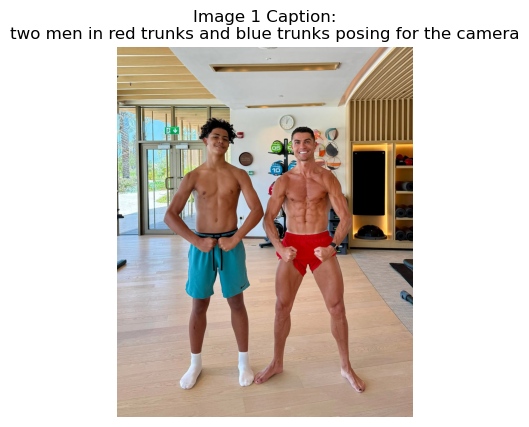

🖼️ Image 1: insta_post/2025-06-15_10-30-21_UTC_1.jpg
🧠 Caption: two men in red trunks and blue trunks posing for the camera
--------------------------------------------------


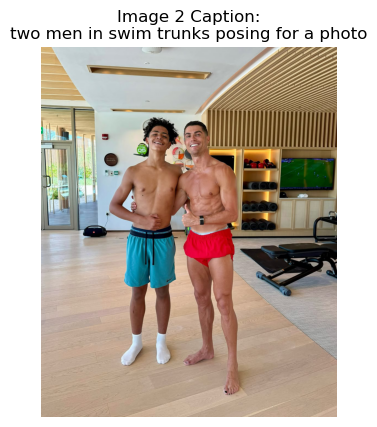

🖼️ Image 2: insta_post/2025-06-15_10-30-21_UTC_2.jpg
🧠 Caption: two men in swim trunks posing for a photo
--------------------------------------------------


In [5]:
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
import matplotlib.pyplot as plt

# Load BLIP captioning model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# List of downloaded images
image_paths = [
    "insta_post/2025-06-15_10-30-21_UTC_1.jpg",
    "insta_post/2025-06-15_10-30-21_UTC_2.jpg"
]

# Analyze each image
for idx, path in enumerate(image_paths, 1):
    # Load image
    image = Image.open(path).convert('RGB')
    
    # Generate caption
    inputs = processor(image, return_tensors="pt")
    output = model.generate(**inputs)
    caption = processor.decode(output[0], skip_special_tokens=True)
    
    # Show image and caption
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Image {idx} Caption:\n{caption}", fontsize=12)
    plt.show()
    
    print(f"🖼️ Image {idx}: {path}")
    print(f"🧠 Caption: {caption}")
    print("-" * 50)